# 1. Install and Import Dependencies

In [13]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r"C:\Users\zainsaqib\Desktop\Tesseract\tesseract.exe"

print(pytesseract.get_tesseract_version())

5.5.0.20241111


In [14]:
!pip3 install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
!pip install stable-baselines3[extra] protobuf==3.20.* gymnasium


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
!pip install mss pyautogui pytesseract


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
#chrome://dino/

In [18]:
from mss import mss
import pyautogui
import cv2
import numpy as np
import pytesseract
from matplotlib import pyplot as plt
import time
import gymnasium as gym
from gymnasium import Env
from gymnasium.spaces import Box, Discrete

# 2. Build the Environment

## 2.1 Create Environment

In [19]:
class WebGame(Env):
    def __init__(self):
        super().__init__()

        # Setup spaces
        self.observation_space = Box(
            low=0,
            high=255,
            shape=(1,83,100),
            dtype=np.uint8
        )

        self.action_space = Discrete(3)

        # Screen capture
        self.cap = mss()

        # Game dimensions
        # Top Left     -> (369,160)
        # Bottom Right -> (987,330)

        self.game_location = {
            'top': 160,
            'left': 369,
            'width': 618,   # 987 - 369
            'height': 170   # 330 - 160
        }

        # GAME OVER dimensions
        # Top Left     -> (578,197)
        # Bottom Right -> (784,224)

        self.done_location = {
            'top': 197,
            'left': 578,
            'width': 206,   # 784 - 578
            'height': 27    # 224 - 197
        }

        self.current_frame = None

    def step(self, action):

        action_map = {
            0: 'space',
            1: 'down',
            2: 'no_op'
        }

        if action != 2:
            pyautogui.press(action_map[action])

        terminated, done_cap = self.get_done()

        observation = self.get_observation()

        reward = 1

        truncated = False

        info = {}

        return observation, reward, terminated, truncated, info

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        time.sleep(1)

        pyautogui.click(x=500, y=200)

        pyautogui.press('space')

        return self.get_observation(), {}

    def render(self):

        if self.current_frame is not None:

            cv2.imshow('Game', self.current_frame)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                self.close()

    def close(self):

        cv2.destroyAllWindows()

    def get_observation(self):

        raw = np.array(
            self.cap.grab(self.game_location)
        )[:, :, :3].astype(np.uint8)

        gray = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)

        resized = cv2.resize(gray, (100,83))

        self.current_frame = resized

        channel = np.reshape(resized, (1,83,100))

        return channel

    def get_done(self):

        done_cap = np.array(
            self.cap.grab(self.done_location)
        )

        gray = cv2.cvtColor(done_cap, cv2.COLOR_BGR2GRAY)

        _, thresh = cv2.threshold(
            gray,
            127,
            255,
            cv2.THRESH_BINARY
        )

        done_strings = ['GAME', 'GAHE']

        done = False

        res = pytesseract.image_to_string(thresh)[:4]

        print(res)

        if res in done_strings:
            done = True

        return done, done_cap

# 2.2 Test Environment

In [20]:
env = WebGame()

C:\Users\zainsaqib\AppData\Local\Temp\ipykernel_12580\1764381298.py:16: DeprecationWarning: mss.mss is deprecated and will be removed in a future release; use mss.MSS instead
  self.cap = mss()


In [21]:
obs=env.get_observation()

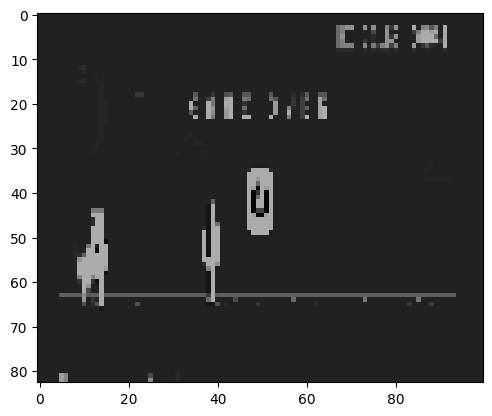

In [22]:
plt.imshow(cv2.cvtColor(obs[0], cv2.COLOR_GRAY2BGR))

In [23]:
done, done_cap = env.get_done()

SAME


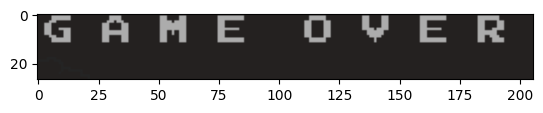

In [24]:
plt.imshow(done_cap)

In [25]:
pytesseract.image_to_string(done_cap)[:4]

'SAME'

In [26]:
done

False

In [27]:
gray = cv2.cvtColor(done_cap, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

text = pytesseract.image_to_string(thresh)

print(text)

SAME OVER



In [28]:
for episode in range(10): 
    obs, info = env.reset()
    done = False  
    total_reward   = 0
    while not done: 
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        done = terminated or truncated
        total_reward  += reward
    print('Total Reward for episode {} is {}'.format(episode, total_reward))    


SAME


GAME
Total Reward for episode 0 is 5


GAME
Total Reward for episode 1 is 3




GAME
Total Reward for episode 2 is 5


GAME
Total Reward for episode 3 is 3


GAME
Total Reward for episode 4 is 3


GAME
Total Reward for episode 5 is 3


GAME
Total Reward for episode 6 is 3


GAME
Total Reward for episode 7 is 3


GAME
Total Reward for episode 8 is 3


GAME
Total Reward for episode 9 is 3


# 3. Train the Model

## 3.1 Create Callback

In [35]:
# Import os for file path management
import os 
# Import Base Callback for saving models
from stable_baselines3.common.callbacks import BaseCallback
# Check Environment    
from stable_baselines3.common import env_checker

In [36]:
env_checker.check_env(env)







GAME






In [38]:
class TrainAndLoggingCallback(BaseCallback):

    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)

        return True

In [39]:
CHECKPOINT_DIR = './train/'
LOG_DIR = './logs/'

In [40]:
callback = TrainAndLoggingCallback(check_freq=1000, save_path=CHECKPOINT_DIR)

## 3.2 Build DQN and Train

In [43]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

In [44]:
env = WebGame() 

C:\Users\zainsaqib\AppData\Local\Temp\ipykernel_12580\1764381298.py:16: DeprecationWarning: mss.mss is deprecated and will be removed in a future release; use mss.MSS instead
  self.cap = mss()


In [ ]:
import os

checkpoints = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.zip')]

if checkpoints:   
    latest = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].replace('.zip', '')))[-1]
    model_path = os.path.j        oin(CHECKPOINT_DIR, latest.replace('.zip', ''))
    print(f"Resuming from:   {model_path}")
    model = DQN.load(model_path, env=env, tensorboard_log=LOG_DIR)
else:
    print("Starting fresh.")
    model = DQN('CnnPolicy', env, tensorboard_log=LOG_DIR, verbose=1,
            buffer_size=100000, learning_starts=1000)

Starting fresh.
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [51]:
model.learn(total_timesteps=100000, callback=callback, reset_num_timesteps=False)

Logging to ./logs/DQN_0


KeyboardInterrupt: 

In [63]:
import os

checkpoints = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.zip')]
latest = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].replace('.zip', '')))[-1]
model_path = os.path.join(CHECKPOINT_DIR, latest.replace('.zip', ''))
print(f"Loading: {model_path}")
model = DQN.load(model_path, env=env)

Loading: ./train/best_model_34000


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


# 4. Test out Model

In [67]:
for episode in range(10): 
    obs, info = env.reset()
    done = False
    total_reward = 0
    while not done: 
        action, _ = model.predict(obs)
        obs, reward, terminated, truncated, info = env.step(int(action))
        done = terminated or truncated
        time.sleep(0.01)
        total_reward += reward
    print('Total Reward for episode {} is {}'.format(episode, total_reward))
    time.sleep(2)

KeyboardInterrupt: 